In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
df=sns.load_dataset('titanic')
df

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.0,0,0,13.0000,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.0000,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.4500,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.0000,C,First,man,True,C,Cherbourg,yes,True


In [3]:
df.to_csv("titanic.csv")

In [4]:
#Part-A:Task-1
print(f"Shape of the dataframe:{df.shape}")
print("="*20)
print("Data Frame Info:")
print("-"*10)
print(df.info())
print("="*20)
print("Data Frame Describe")
print("-"*10)
print(df.describe())

Shape of the dataframe:(891, 15)
Data Frame Info:
----------
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None
Data Frame Describe
--------

In [5]:
# printing missing values percentage in every column
print("Percentage of missing values in every column")
print('-'*20)
missing_percentage = df.isna().mean()*100
print(missing_percentage)

Percentage of missing values in every column
--------------------
survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64


In [6]:
# dropping unnecessary columns
# drop the unessary columns
columns_to_be_dropped = [
    "class",
    "who",
    "adult_male",
    "embark_town",
    "alone",
    "alive"
]
df.drop(columns = columns_to_be_dropped, inplace = True)
print(f"Columns {columns_to_be_dropped} are dropped from the data frame")
print("info() after dropping unnessasary columns")
print("-" * 20)
print(df.info())
print("-" * 20)

Columns ['class', 'who', 'adult_male', 'embark_town', 'alone', 'alive'] are dropped from the data frame
info() after dropping unnessasary columns
--------------------
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   survived  891 non-null    int64   
 1   pclass    891 non-null    int64   
 2   sex       891 non-null    str     
 3   age       714 non-null    float64 
 4   sibsp     891 non-null    int64   
 5   parch     891 non-null    int64   
 6   fare      891 non-null    float64 
 7   embarked  889 non-null    str     
 8   deck      203 non-null    category
dtypes: category(1), float64(2), int64(4), str(2)
memory usage: 57.0 KB
None
--------------------


In [7]:
# impute age
df["age"] = df["age"].fillna(df["age"].median())

# handle the embarked column
df.dropna(subset = ["embarked"], inplace=True)

# remove deck column
df.drop(columns = ["deck"], inplace = True)

print(f"Columns age, embarked and deck are handled for missing values")
print("info() after handling missing values")
print("-" * 20)
print(df.info())
print("-" * 20)

Columns age, embarked and deck are handled for missing values
info() after handling missing values
--------------------
<class 'pandas.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  889 non-null    int64  
 1   pclass    889 non-null    int64  
 2   sex       889 non-null    str    
 3   age       889 non-null    float64
 4   sibsp     889 non-null    int64  
 5   parch     889 non-null    int64  
 6   fare      889 non-null    float64
 7   embarked  889 non-null    str    
dtypes: float64(2), int64(4), str(2)
memory usage: 62.5 KB
None
--------------------


In [8]:
df.to_csv(path_or_buf = 'clean_df.csv', mode = 'w', index = False)

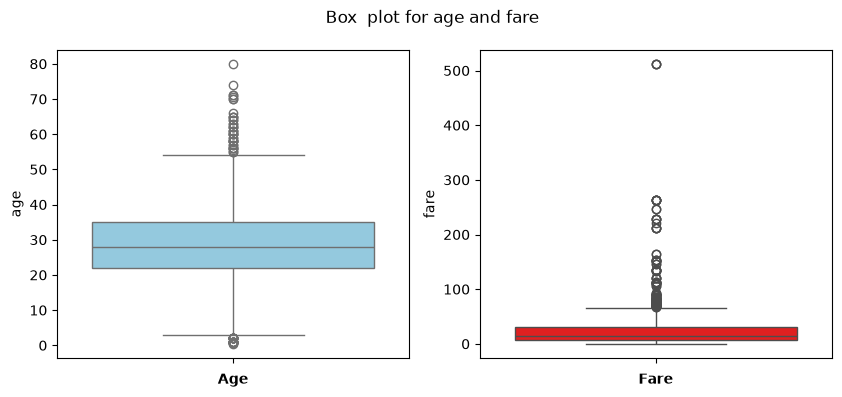

In [9]:
# Univariate Analysis
# Boxplot
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

age_plot = sns.boxplot(df["age"],ax=ax1,color='skyblue',patch_artist=True)
ax1.set_xlabel("Age", fontweight="bold")

fare_plot = sns.boxplot(df["fare"],ax=ax2,color='red',patch_artist=True)
ax2.set_xlabel("Fare", fontweight="bold")
plt.suptitle("Box  plot for age and fare")

plt.show()

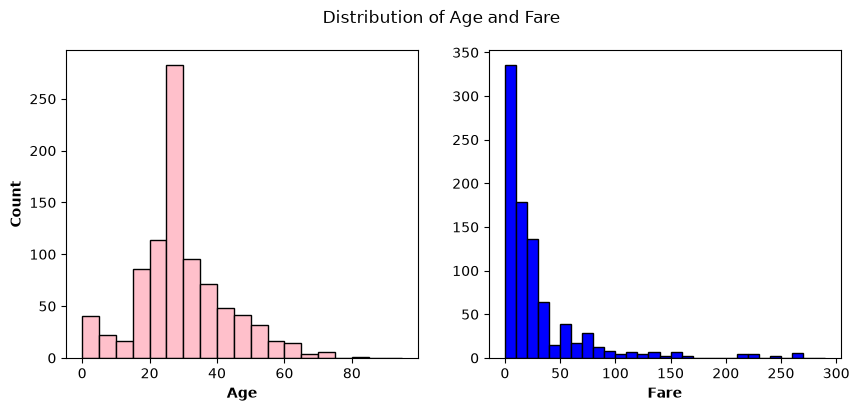

In [10]:
# Histogram
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))
bins_for_age = np.arange(0, 100, 5)
bins_for_fare = np.arange(0, 300, 10)

ax1.hist(df["age"], bins=bins_for_age, color="pink", edgecolor="black")
ax1.set_xlabel("Age", fontweight="bold")
ax1.set_ylabel("Count", fontweight="bold")

ax2.hist(df["fare"], bins=bins_for_fare, color="blue", edgecolor="black")
ax2.set_xlabel("Fare", fontweight="bold")

plt.suptitle("Distribution of Age and Fare")

plt.show()

In [11]:
# Outliers in age and fare columns
cols = ['age','fare']
for col in cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
  print(f"Outliers for columns : {col}")
  print(f"IQR : {IQR:.2f} | Bounds : [{lower_bound:.2f},{upper_bound:>2f}]")
  print(f"Number of outliers found:{len(outliers)}")


Outliers for columns : age
IQR : 13.00 | Bounds : [2.50,54.500000]
Number of outliers found:65
Outliers for columns : fare
IQR : 23.10 | Bounds : [-26.76,65.656300]
Number of outliers found:114


In [12]:
# calculate mean, median and mode for age and fare columns
age_mean = float(df["age"].mean()).__round__(2)
age_median = float(df["age"].median())
age_mode = float(df["age"].mode()[0])

fare_mean = float(df["fare"].mean()).__round__(2)
fare_median = float(df["fare"].median())
fare_mode = float(df["fare"].mode()[0])

print(f"{"column":<10}{"Mean":<10}{"Median":<10}{"Mode":<10}")
print("-" * 40)
print(f"{"Age":<10}{age_mean:<10}{age_median:<10}{age_mode:<10}")
print(f"{"Fare":<10}{fare_mean:<10}{fare_median:<10}{fare_mode:<10}")


column    Mean      Median    Mode      
----------------------------------------
Age       29.32     28.0      28.0      
Fare      32.1      14.4542   8.05      


Skweness of age and fare columns

According to our data for age column as Mean > Median, long tail extends towards right and difference between mean and median is not so large, the distribution can be said as moderately right-skewed
   for fare column as Mean > Median -> long tail extends towards right and difference between mean and median and mode is large, the distribution can be said as highly right-skewed
   

In [13]:
# Bivariate Analysis
# survival rate % by sex
no_of_survived = df[df["survived"] == 1].shape[0]
no_of_male_survived = df[(df["sex"] == "male") & (df["survived"] == 1)].shape[0]
no_of_female_survived = df[(df["sex"] == "female") & (df["survived"] == 1)].shape[0]
print("Survival rate by gender")
print("-" * 25)
print(f"{"sex"}  {"survival rate"}")
print("-" * 25)
print(f"{"male"}  {((no_of_male_survived / no_of_survived) * 100) :.2f}")
print(f"{"female"}  {((no_of_female_survived / no_of_survived) * 100) :.2f}")

Survival rate by gender
-------------------------
sex  survival rate
-------------------------
male  32.06
female  67.94


In [14]:
# survival rate % by pclass
print("Survival rate by pclass")
print("-" * 25)
print(f"{"pclass"} {"survival rate"}")
print("-" * 25)
for pclass, rate in (df.groupby("pclass")["survived"].agg("mean") * 100).items():
    print(f"{pclass:<10}{rate:.2f}")

Survival rate by pclass
-------------------------
pclass survival rate
-------------------------
1         62.62
2         47.28
3         24.24


In [15]:
# survival rate % by both pclass and sex
print("Combined Survival rate")
print("-" * 20)
survival_rate=df.groupby(['pclass',  'sex'])['survived'].mean() * 100
print(survival_rate.to_frame().round(2))

Combined Survival rate
--------------------
               survived
pclass sex             
1      female     96.74
       male       36.89
2      female     92.11
       male       15.74
3      female     50.00
       male       13.54


In [16]:
# computing correlation matrix
corr_columns = ["survived","pclass","age","sibsp","parch","fare"]
corr_matrix = df[corr_columns].corr()
print(corr_matrix)

          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


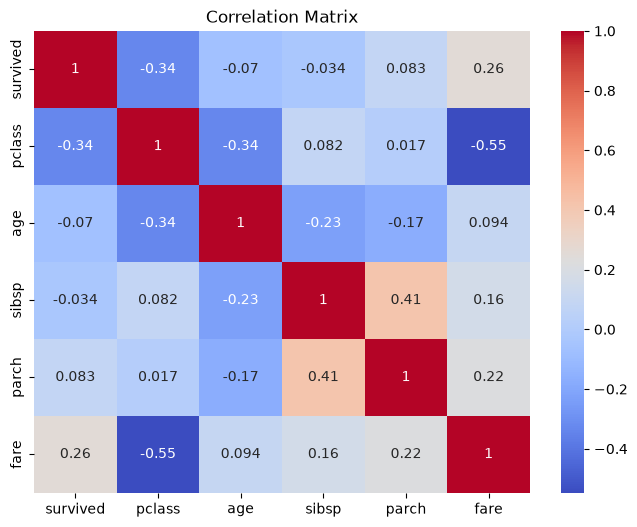

In [17]:
# drawing heat map
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [18]:
# finding two strongest correlations
corr = corr_matrix.abs()
for i in range(len(corr)):
  corr.iloc[i,i] = 0
print("Top 2 strongest correlations")
print("-" * 20)
print(corr.stack().sort_values(ascending=False).head(4))

Top 2 strongest correlations
--------------------
fare    pclass    0.548193
pclass  fare      0.548193
parch   sibsp     0.414542
sibsp   parch     0.414542
dtype: float64


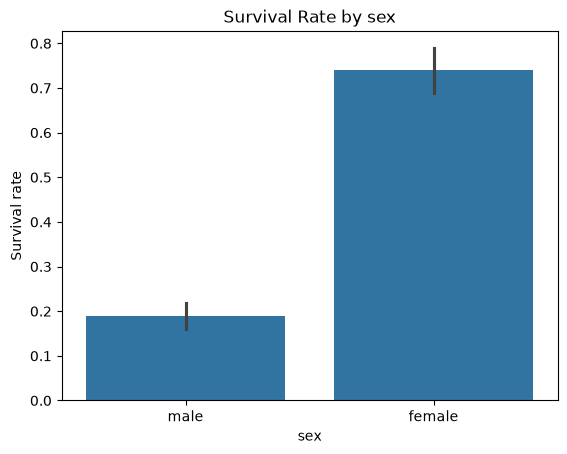

'The chart shows more survival rate for female passengers than male passengers.\nThis indicates that out of 100% survival rate 80% are female passengers and 20% are male passengers  in the dataset'

In [19]:
# Multivariate data story
# Survival by sex class
sns.barplot(data=df,x="sex",y="survived")
plt.title("Survival Rate by sex")
plt.ylabel("Survival rate")
plt.show()
"""The chart shows more survival rate for female passengers than male passengers.
This indicates that out of 100% survival rate 80% are female passengers and 20% are male passengers  in the dataset"""

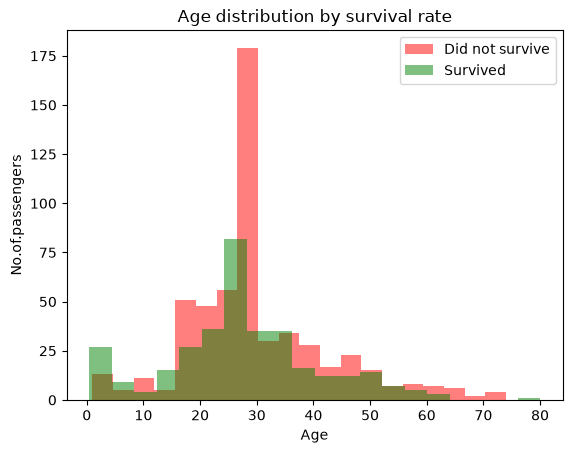

'In this chart the survival rate of the no.of.passengers of age approximately between 20-50 is very less'

In [20]:
# Age distribution by survival
plt.hist(df[df["survived"]==0]["age"],bins=20,alpha=0.5,label="Did not survive",color="r")
plt.hist(df[df["survived"]==1]["age"],bins=20,alpha=0.5,label="Survived",color="g")
plt.title("Age distribution by survival rate")
plt.xlabel("Age")
plt.ylabel("No.of.passengers")
plt.legend()
plt.show()
"""In this chart the survival rate of the no.of.passengers of age approximately between 20-50 is very less"""

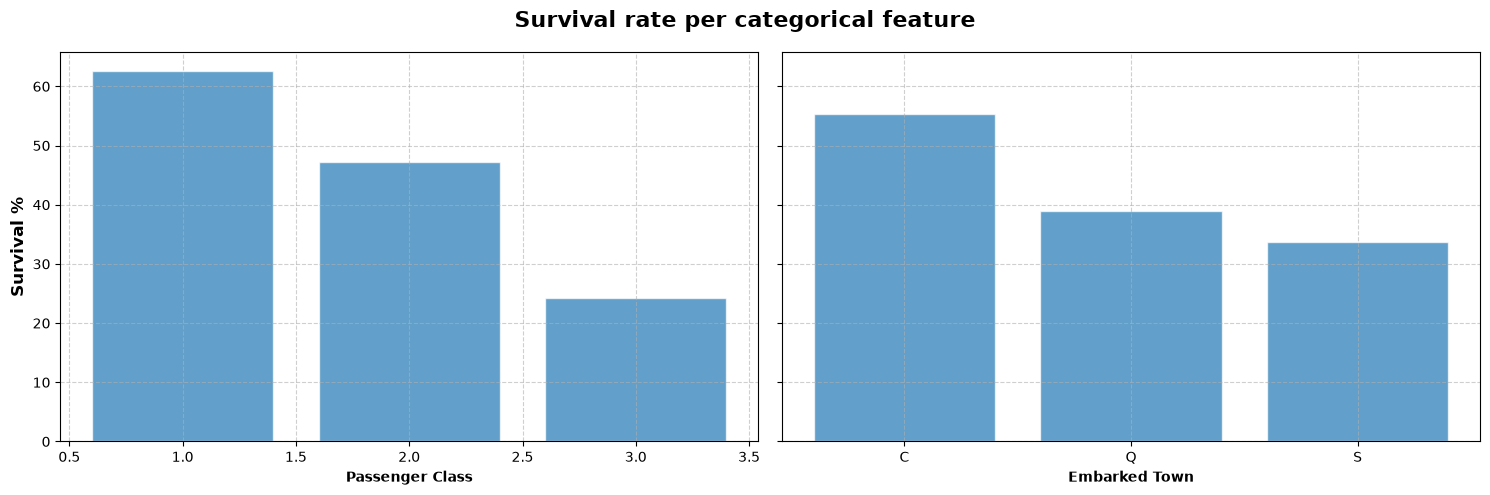

'The chart represents the survival rate for categorial feature, here according to the passenger class the survival rate for pclass 1(nearly 60%) is more than\nthe survival rate when compared to pclass2 and pclass3. And when compared to embarked town the people who boarded from Cherbourg has the highest survival rate where\nas the people who boarded from Southampton has the least survival rate'

In [21]:
# Draw a pair plot with Y axis as survived column
cat_cols = ["pclass", "embarked"]
fig, axes = plt.subplots(nrows=1, ncols=len(cat_cols), figsize=(15, 5), sharey=True)
fig.suptitle("Survival rate per categorical feature", fontsize=16, fontweight='bold')
desc = {
    "pclass": "Passenger Class",
    "embarked": "Embarked Town"
}
for i, col in enumerate(cat_cols):
    agg = df.groupby(col)["survived"].mean() * 100
    ax = axes[i]
    ax.bar(agg.index, agg.values, alpha=0.7, edgecolor='white')
    ax.set_xlabel(desc[col], fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.6)
axes[0].set_ylabel("Survival %", fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()
"""The chart represents the survival rate for categorial feature, here according to the passenger class the survival rate for pclass 1(nearly 60%) is more than
the survival rate when compared to pclass2 and pclass3. And when compared to embarked town the people who boarded from Cherbourg has the highest survival rate where
as the people who boarded from Southampton has the least survival rate"""

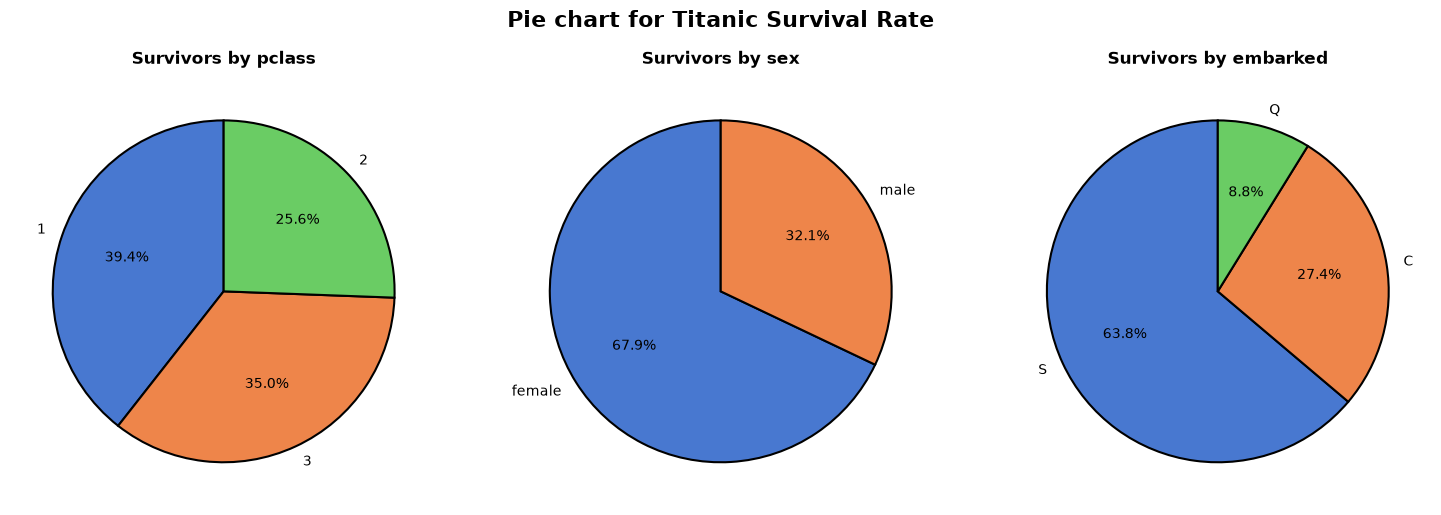

' According to the pie charts, the percentage of people who survived from pclass from pclass 3 where as\naccording to gender female percentage of survivours is very much big when compared to male and finally when coming to embarked town the\npassengers who boarded at Southampton survived more when compared to other two towns'

In [22]:
features_for_pie = ["pclass", "sex", "embarked"]
fig, axes = plt.subplots(nrows=1, ncols=len(features_for_pie), figsize=(15, 5))
for i, feature in enumerate(features_for_pie):
    ax = axes[i]
    counts = df[df["survived"] == 1][feature].value_counts()
    ax.pie(counts.values,
           labels=counts.index,
           autopct='%1.1f%%',
           startangle=90,
           colors=sns.color_palette("muted"),
           wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})
    ax.set_title(f'Survivors by {feature}', fontweight='bold', pad=10)
fig.suptitle("Pie chart for Titanic Survival Rate", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
""" According to the pie charts, the percentage of people who survived from pclass from pclass 3 where as
according to gender female percentage of survivours is very much big when compared to male and finally when coming to embarked town the
passengers who boarded at Southampton survived more when compared to other two towns"""

In [23]:
scaler_age = StandardScaler()
scalar_fare = StandardScaler()
df["age_z"] = scaler_age.fit_transform(df[["age"]])
df["fare_z"] = scalar_fare.fit_transform(df[["fare"]])
print("Before Standardization")
print(f"Age Mean: {df["age"].mean():.2f}")
print(f"Age Std: {df["age"].std():.2f}")
print(f"Fare Mean: {df["fare"].mean():.2f}")
print(f"Fare Std: {df["fare"].std():.2f}")
print("-"*20)
print("After Standardization")
print(f"Age Mean: {df["age_z"].mean():.2f}")
print(f"Age Std: {df["age_z"].std():.2f}")
print(f"Fare Mean: {df["fare_z"].mean():.2f}")
print(f"Fare Std: {df["fare_z"].std():.2f}")


Before Standardization
Age Mean: 29.32
Age Std: 12.98
Fare Mean: 32.10
Fare Std: 49.70
--------------------
After Standardization
Age Mean: 0.00
Age Std: 1.00
Fare Mean: 0.00
Fare Std: 1.00
